In this notebook we'll be working on the Exploratory Data Analysis of the dataset created in the previous notebook. We'll try to respond to the business requests, such as identifying the "best Italian Municipalities for strategic investment", discovering what towns have the highest accident rates, total accidents, etc.

P.S. Given that our company operates in the field of road traffic management and risk prevention, our assumption is that strategic investments should be directed toward areas with the highest concentration and density of traffic accidents. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df_historical = pd.read_csv("data/historical_accidents.csv")

In [4]:
df_historical

,Codice_Comune,Codice_Regione,Comune,Regione,Anno,Incidenti,Feriti,Morti,Indice Fatalità,Indice Lesività
0,1001,1,Agliè,Piemonte,2014,6,11,0,0.0,1.83
1,1001,1,Agliè,Piemonte,2015,5,9,0,0.0,1.80
2,1001,1,Agliè,Piemonte,2016,5,8,0,0.0,1.60
3,1001,1,Agliè,Piemonte,2017,0,0,0,0.0,0.00
4,1001,1,Agliè,Piemonte,2018,1,1,0,0.0,1.00
...,...,...,...,...,...,...,...,...,...,...
85900,111107,20,Villaspeciosa,Sardegna,2020,2,3,0,0.0,1.50
85901,111107,20,Villaspeciosa,Sardegna,2021,5,7,0,0.0,1.40
85902,111107,20,Villaspeciosa,Sardegna,2022,1,1,0,0.0,1.00
85903,111107,20,Villaspeciosa,Sardegna,2023,4,5,0,0.0,1.25


In [ ]:
df_historical.info() #a quick check

<class 'pandas.DataFrame'>
RangeIndex: 85905 entries, 0 to 85904
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Codice_Comune    85905 non-null  int64  
 1   Codice_Regione   85905 non-null  int64  
 2   Comune           85894 non-null  str    
 3   Regione          85905 non-null  str    
 4   Anno             85905 non-null  int64  
 5   Incidenti        85905 non-null  int64  
 6   Feriti           85905 non-null  int64  
 7   Morti            85905 non-null  int64  
 8   Indice Fatalità  85905 non-null  float64
 9   Indice Lesività  85905 non-null  float64
dtypes: float64(2), int64(6), str(2)
memory usage: 6.6 MB


In [ ]:
# aggregating data at a national level for each year
national_trend = df_historical.groupby("Anno")[["Incidenti", "Morti", "Feriti"]].sum().reset_index()

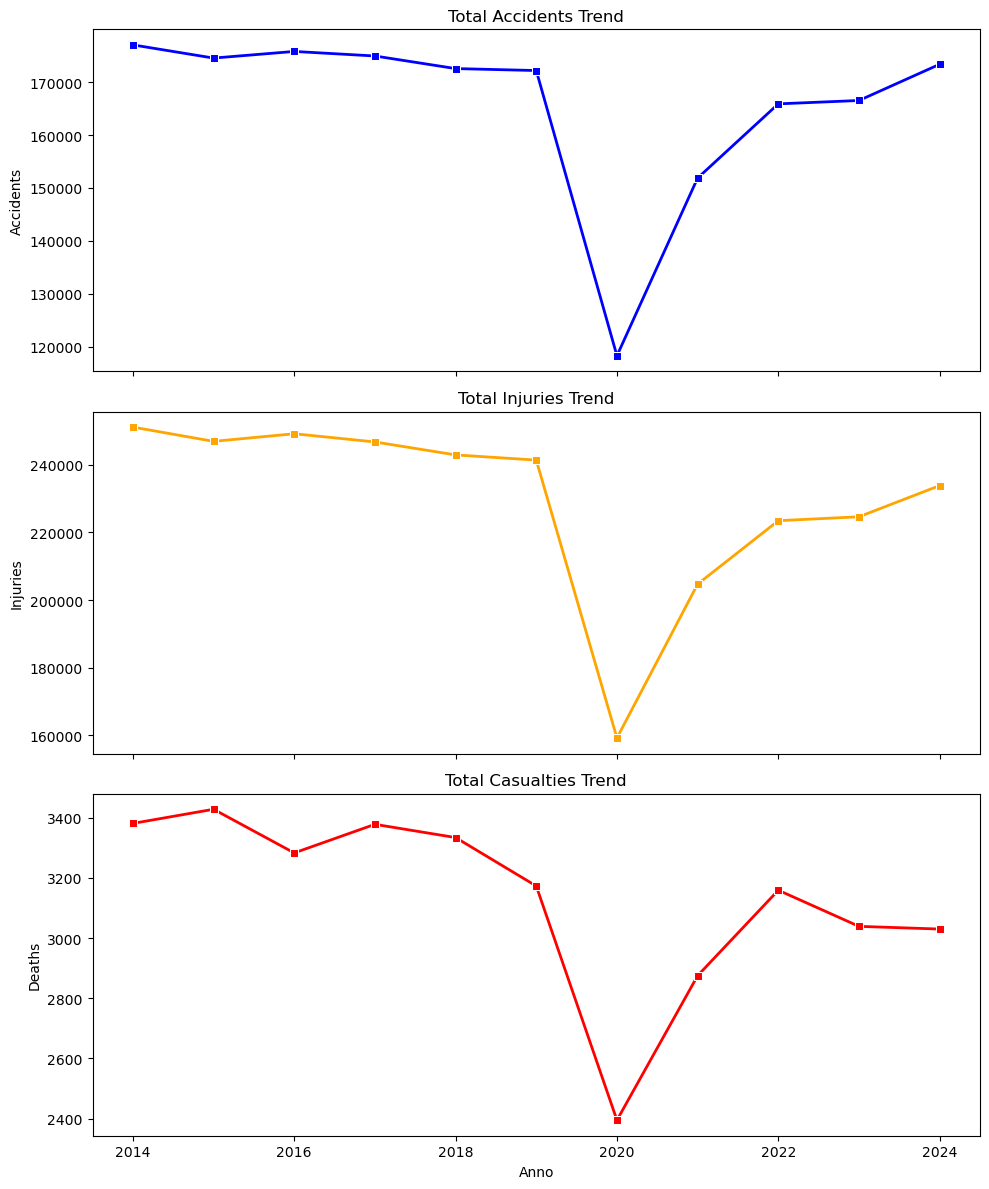

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
acc_plot = sns.lineplot(
    data=national_trend, x="Anno", y="Incidenti", 
    marker="s", color="blue", ax=axes[0], linewidth=2
)
axes[0].set_title("Total Accidents Trend", fontsize=12)
axes[0].set_ylabel("Accidents")

inj_plot = sns.lineplot(
    data=national_trend, x="Anno", y="Feriti", 
    marker="s", color="orange", ax=axes[1], linewidth=2
)
axes[1].set_title("Total Injuries Trend", fontsize=12)
axes[1].set_ylabel("Injuries")

death_plot = sns.lineplot(
    data=national_trend, x="Anno", y="Morti", 
    marker="s", color="red", ax=axes[2], linewidth=2
)
axes[2].set_title("Total Casualties Trend", fontsize=12)
axes[2].set_ylabel("Deaths")

plt.tight_layout()
plt.show();

Based on the historical data, we can observe that except for specific anomalies, the baseline trends for accidents, injuries, and casualties remain relatively stable across the years. As expected, there is a sharp drop in all metrics during the year 2020. This was strictly caused by the nationwide pandemic lockdowns and travel restrictions. Following 2020, as restrictions were gradually lifted, the trends steadily rose back to historical baselines and returned to normality.

In [ ]:
#Indexes are recalculated on national totals to avoid unweighted bias from small municipalities
national_trend["Weighted_Fatality_Index"] = national_trend["Morti"] / national_trend["Incidenti"]
national_trend["Weighted_Injury_Index"] = national_trend["Feriti"] / national_trend["Incidenti"]

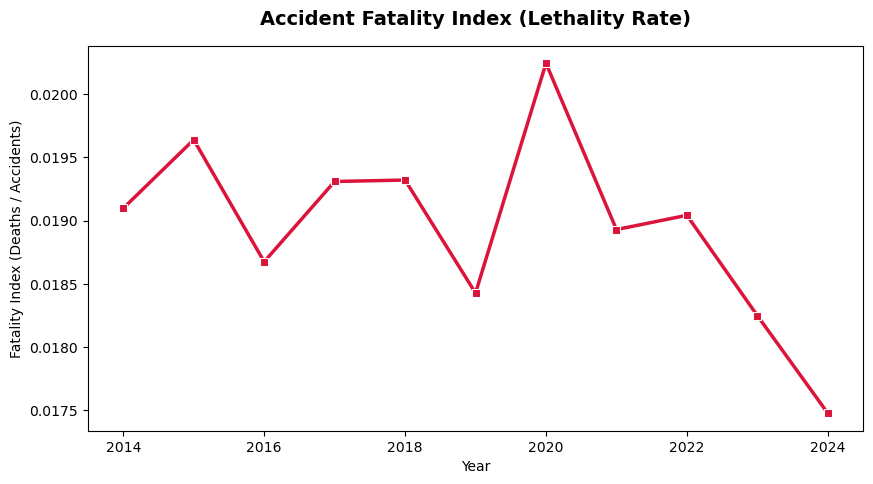

In [23]:
plt.figure(figsize=(10, 5))
fatality_plot = sns.lineplot(
    data=national_trend, 
    x="Anno", 
    y="Weighted_Fatality_Index", 
    marker="s", 
    linewidth=2.5, 
    color="crimson"
)
plt.title("Accident Fatality Index (Lethality Rate)", fontsize=14, pad=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Fatality Index (Deaths / Accidents)");

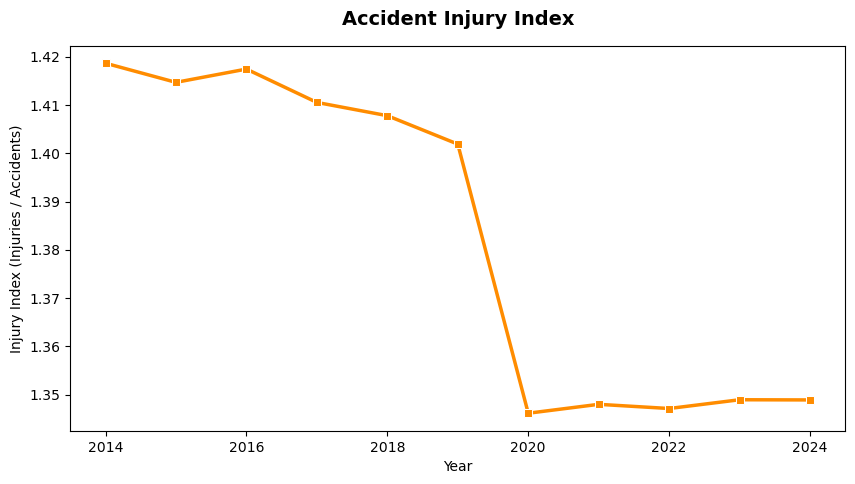

In [26]:
plt.figure(figsize=(10, 5))
inj_ind_plot = sns.lineplot(
    data=national_trend, 
    x="Anno", 
    y="Weighted_Injury_Index", 
    marker="s", 
    linewidth=2.5, 
    color="darkorange"
)
plt.title("Accident Injury Index", fontsize=14, pad=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Injury Index (Injuries / Accidents)");

Analizying the severity and nature of traffic accidents across Italy we can extract some insights for risk prevention.

While the absolute number of accidents returned toward pre-pandemic baselines after 2020, the Injury Index has stabilized at a lower level.
This shift suggests a positive structural change in urban mobility. The post-2020 period saw an acceleration of municipal experiments with "Zone 30" (30 km/h speed limits in residential areas) and increased micromobility frameworks. Lower urban speeds directly correlate with fewer injuries per crash, showcasing a potential area where traffic management investments are actively yielding results.

Conversely, the Fatality Index experienced a sharp peak during 2020. This reveals a counter-intuitive phenomenon as we observed fewer total accidents, but a higher ratio of lethal outcomes.
Hypothetically, during lockdowns and periods of reduced traffic density, average driving speeds on major roads increased significantly due to empty lanes, leading to more severe and fatal outcomes when a crash does occur.

To directly address the core business goal of identifying which specific towns and municipalities present the highest risk, we shift our focus from the macro-regional view to a granular municipal analysis.

In [27]:
muni_group = df_historical.groupby("Comune")[["Incidenti", "Feriti", "Morti"]].sum().reset_index()

In [ ]:
#getting the Top 15 municipalities for each metric independently
top_accidents = muni_group.sort_values(by="Incidenti", ascending=False).head(15)
top_injuries = muni_group.sort_values(by="Feriti", ascending=False).head(15)
top_deaths = muni_group.sort_values(by="Morti", ascending=False).head(15)

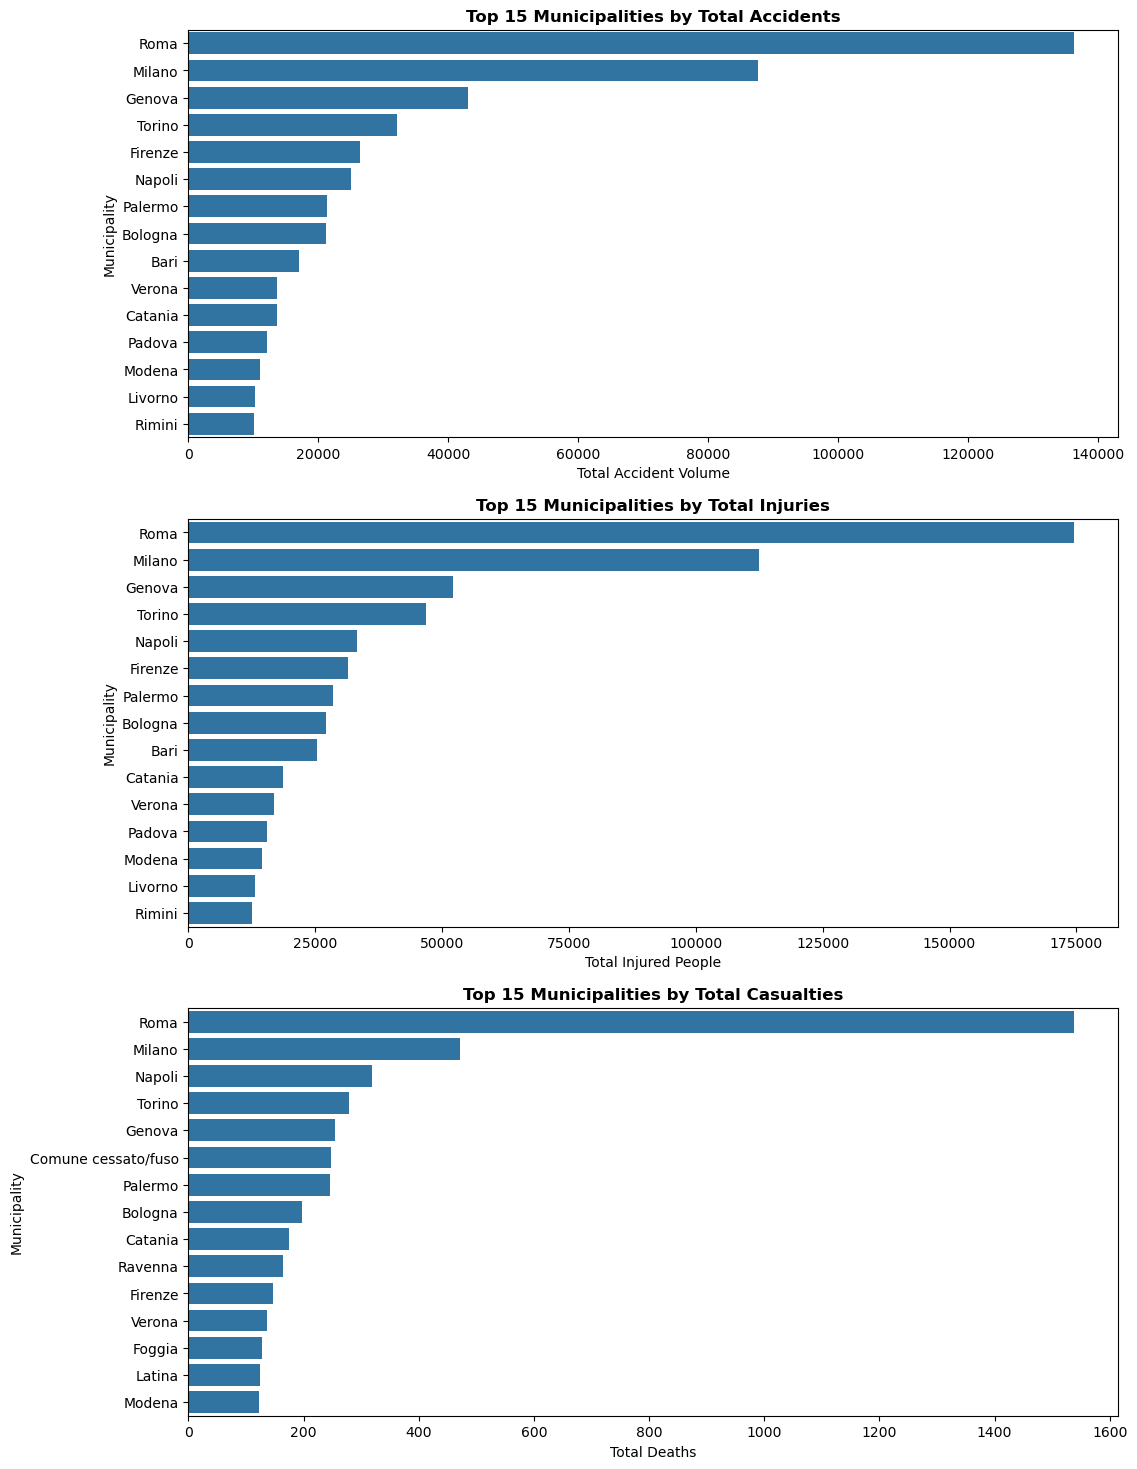

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
acc_muni = sns.barplot(
    data=top_accidents, 
    x="Incidenti", 
    y="Comune", 
    ax=axes[0]
)
axes[0].set_title("Top 15 Municipalities by Total Accidents", fontsize=12, weight="bold")
axes[0].set_xlabel("Total Accident Volume")
axes[0].set_ylabel("Municipality")

inj_muni = sns.barplot(
    data=top_injuries, 
    x="Feriti", 
    y="Comune", 
    ax=axes[1]
)
axes[1].set_title("Top 15 Municipalities by Total Injuries", fontsize=12, weight="bold")
axes[1].set_xlabel("Total Injured People")
axes[1].set_ylabel("Municipality")

death_muni = sns.barplot(
    data=top_deaths, 
    x="Morti", 
    y="Comune",
    ax=axes[2]
)
axes[2].set_title("Top 15 Municipalities by Total Casualties", fontsize=12, weight="bold")
axes[2].set_xlabel("Total Deaths")
axes[2].set_ylabel("Municipality")

plt.show()

By breaking down the top 15 municipalities across all three main metrics (Accidents, Injuries, and Casualties), we can separate simple high-traffic areas from truly dangerous zones.
As expected, Rome and Milan experience the highest absolute numbers of accidents and injuries due to their massive populations and daily commuting flows. 
While Milan manages to keep its total death toll relatively low compared to its accident volume, Roma shows a spike in deaths. This indicates that accidents in the capital are structurally more lethal, potentially due to higher speeds on urban arterial roads (e.g. Grande Raccordo Anulare) or infrastructural challenges.
Cities like Ravenna, Foggia, Perugia, and Latina do not appear in the top rankings for total accidents or injuries. However, they rank highly in total deaths. This proves that these municipalities suffer from low-frequency but extremely high-severity crashes, hypotethically associated with extra-urban roads and high-speed transit corridors.

Ultimately, Rome and Milan are ideal for large-scale investments in traffic congestion management, smart intersections, and micro-mobility injury prevention.
In other location like Ravenna and Perugia the company should focus on high-velocity enforcement-like systems, as their primary crisis is loss of life rather than minor crashes.

We'll now shift our focus to the second dataset. We will analyze the relationship between municipalities' dimensions (such as population and surface area) and their safety performance metrics.

In [33]:
municipalities = pd.read_csv("data/municipality_indicators.csv")

In [34]:
municipalities

,Comune,Popolazione_Legale,Superficie(Kmq),Media Incidenti,Media Feriti,Media Morti,Incidenti_Pro_Capite_1000,Lesività_Pro_Capite_1000,Densità_Incidenti_Kmq
0,Agliè,2562.0,13.1463,3.090909,5.090909,0.090909,1.206444,2.022568,0.235116
1,Airasca,3660.0,15.7393,7.363636,12.545455,0.181818,2.011923,3.477397,0.467850
2,Ala di Stura,467.0,46.3316,0.454545,0.545455,0.000000,0.973331,1.167997,0.009811
3,Albiano d'Ivrea,1637.0,11.7397,4.000000,6.545455,0.181818,2.443494,4.109513,0.340724
4,Almese,6331.0,17.8741,4.545455,6.090909,0.090909,0.717968,0.976436,0.254304
...,...,...,...,...,...,...,...,...,...
7891,Villaputzu,4509.0,181.3947,6.000000,8.750000,0.625000,1.330672,2.079175,0.033077
7892,Villasalto,989.0,130.3596,2.250000,3.250000,0.125000,2.275025,3.412538,0.017260
7893,Villasimius,3705.0,58.1781,6.750000,9.250000,0.625000,1.821862,2.665317,0.116023
7894,Villasor,6599.0,86.8137,13.000000,19.625000,1.375000,1.969995,3.182300,0.149746


In [35]:
#a quick check
municipalities.info()

<class 'pandas.DataFrame'>
RangeIndex: 7896 entries, 0 to 7895
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Comune                     7895 non-null   str    
 1   Popolazione_Legale         7896 non-null   float64
 2   Superficie(Kmq)            7896 non-null   float64
 3   Media Incidenti            7896 non-null   float64
 4   Media Feriti               7896 non-null   float64
 5   Media Morti                7896 non-null   float64
 6   Incidenti_Pro_Capite_1000  7896 non-null   float64
 7   Lesività_Pro_Capite_1000   7896 non-null   float64
 8   Densità_Incidenti_Kmq      7896 non-null   float64
dtypes: float64(8), str(1)
memory usage: 555.3 KB


In [36]:
#some descriptive statistics
municipalities.describe()

,Popolazione_Legale,Superficie(Kmq),Media Incidenti,Media Feriti,Media Morti,Incidenti_Pro_Capite_1000,Lesività_Pro_Capite_1000,Densità_Incidenti_Kmq
count,7.896000e+03,7896.000000,7896.000000,7896.000000,7896.000000,7896.000000,7896.000000,7896.000000
mean,7.475954e+03,38.261090,20.997814,29.070463,0.397255,1.770248,2.681242,0.622544
std,4.152719e+04,50.823422,190.368246,245.515926,1.923758,1.431216,2.267399,1.602071
min,3.100000e+01,0.122200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.880000e+02,11.470625,1.000000,1.454545,0.000000,0.838054,1.238037,0.041693
50%,2.411500e+03,22.456900,3.387500,5.090909,0.111111,1.492537,2.240879,0.149305
75%,6.240000e+03,44.756775,11.109848,16.363636,0.363636,2.329700,3.480675,0.518535
max,2.749031e+06,1288.187500,12391.090909,15869.000000,139.818182,19.360269,32.828283,43.807038


The average population of an Italian municipality is 7,476, but the median is only 2,411. This difference indicates that the majority of Italian towns are very small, meaning absolute crash volumes will cluster in just a few big urban spots.

While the "Media Incidenti" mean is 20.9 accidents per year per municipality, the median is 3.39. This indicates that most municipalities experience fewer than accidents per year, while a handful of large metropolitan outliers push the national average up (std is over 190).

Looking at the "Incidenti_Pro_Capite_1000", the average is 1.77 accidents per 1,000 residents. However, the maximum value reaches 19.36, indicating that there are municipalities where the statistical probability of having an accident is higher than the national average. These high-rate, small-population locations represent hidden risk hubs perfect for safety interventions.

The median density is low, 0.15 accidents per Kmq, but the maximum hits 43.80. For our business, targeting municipalities in the fourth quartile will allow the company to cover more accidents with fewer physical sensor installations.

In [37]:
top_15_acc_pro_cap = municipalities.sort_values(by="Incidenti_Pro_Capite_1000", ascending=False).head(15)

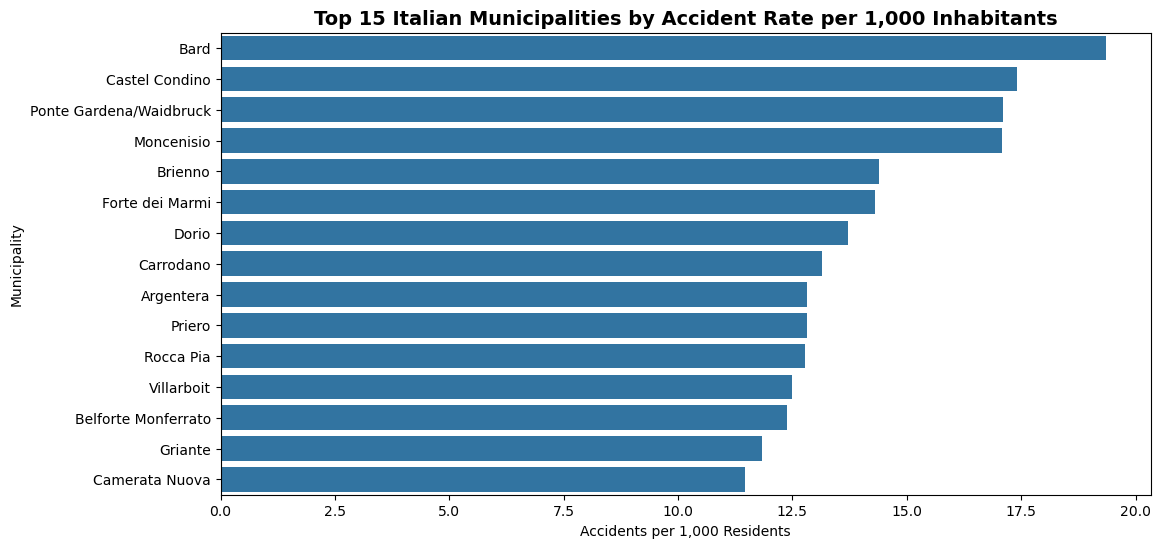

In [40]:
plt.figure(figsize=(12, 6))
acc_rate_plot = sns.barplot(
    data=top_15_acc_pro_cap, 
    x="Incidenti_Pro_Capite_1000", 
    y="Comune"
)

plt.title("Top 15 Italian Municipalities by Accident Rate per 1,000 Inhabitants", fontsize=14, weight="bold")
plt.xlabel("Accidents per 1,000 Residents")
plt.ylabel("Municipality")
plt.show();

Large hubs like Milan and Rome disappear from this top 15 chart, indicating that while big cities dominate absolute numbers, their population-adjusted risk is heavily diluted. Larger urban sizes do not automatically mean higher individual risk of an accident.
The municipalities topping this chart represent critical areas where specific local factors, such as dangerous infrastructural or heavy seasonal tourist traffic inflate the statistical risk for each resident. 

In [39]:
top15_density = municipalities.sort_values(by="Densità_Incidenti_Kmq", ascending=False).head(15)

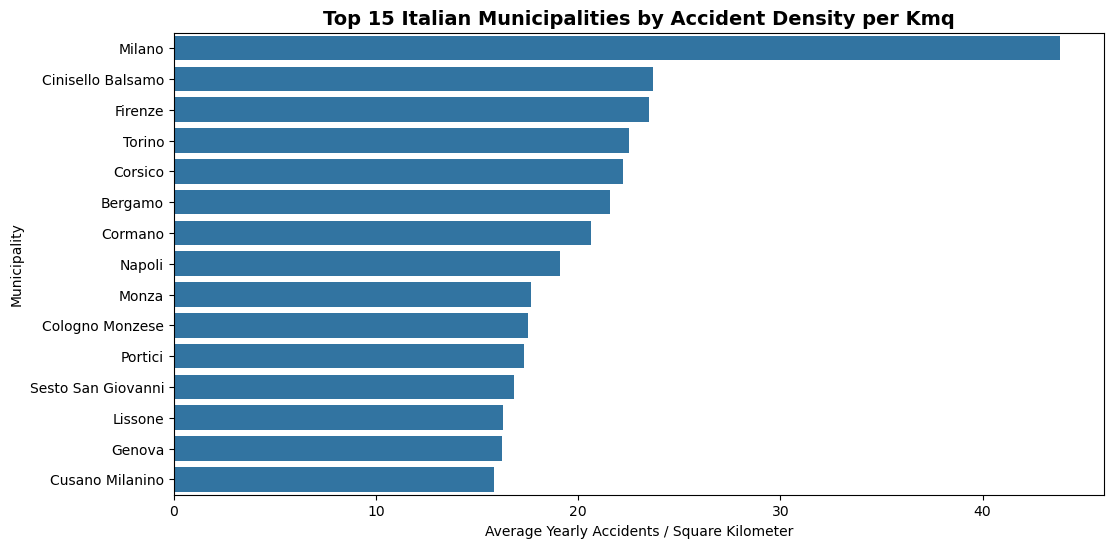

In [41]:
plt.figure(figsize=(12, 6))
density_mun_plot = sns.barplot(
    data=top15_density, 
    x="Densità_Incidenti_Kmq", 
    y="Comune"
)

plt.title("Top 15 Italian Municipalities by Accident Density per Kmq", fontsize=14, weight="bold")
plt.xlabel("Average Yearly Accidents / Square Kilometer")
plt.ylabel("Municipality")
plt.show()

High-density areas are clusters where accidents are tightly packed into small geographic zones. For our business, in these cities we can cover a high percentage of local traffic risk using a very small number of physical intervenction.

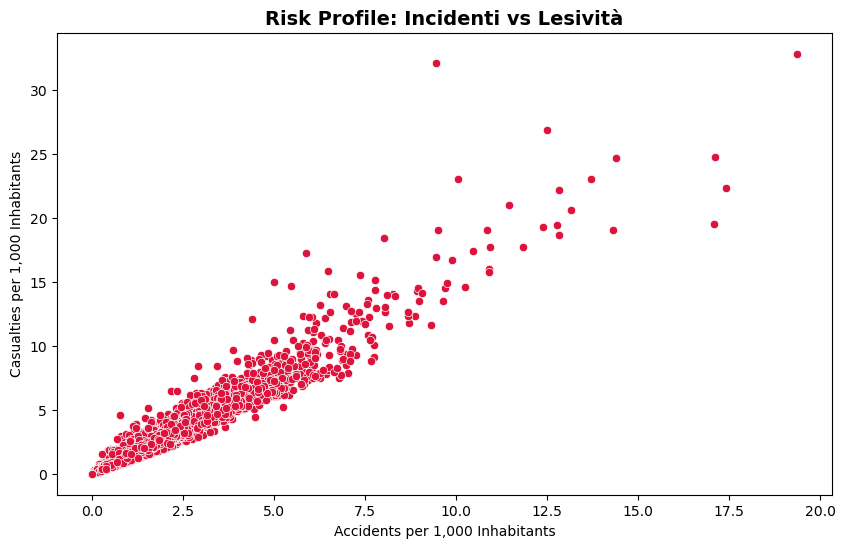

In [56]:
scatter = plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=municipalities,
    x="Incidenti_Pro_Capite_1000",
    y="Lesività_Pro_Capite_1000",
    color='crimson'
)
plt.title("Risk Profile: Incidenti vs Lesività", fontsize=14, weight="bold")
plt.xlabel("Accidents per 1,000 Inhabitants")
plt.ylabel("Casualties per 1,000 Inhabitants")
plt.show()

The scatter plot reveals a positive diagonal distribution. This visually confirms a near-perfect linear relationship, indicating that, across Italy, as the frequency of car crashes increases relative to the population, the number of casualties scales in proportion. This could prove that the severity of traffic accidents (aka how many injuries/deaths are generated per crash) remains statistically constant across the country, regardless of whether it happens in a massive metropolitan area or a small rural town.

To conclude our analysis, we'll scale up from individual municipalities to a macro-regional perspective. 

In [57]:
df_fleet = pd.read_csv("data/regiona_fleet_metrics.csv")

In [58]:
df_fleet

,Regione,Incidenti,Feriti,Morti,Popolazione_Legale,Superficie(Kmq),Parco_Auto_2024,Veicoli_Per_Kmq,Motorizzazione_Pro_Capite_1000,Rapporto Incidenti/Veicoli
0,Abruzzo,33053,48021,816,1275950.0,10831.7158,923548,85.263315,723.812062,35.789152
1,Basilicata,9991,15902,392,541168.0,10073.1768,391305,38.846236,723.074905,25.532513
2,Calabria,29807,48183,1043,1855454.0,15219.2985,1376514,90.445299,741.874495,21.653975
3,Campania,104813,153975,2456,5624420.0,13675.6929,3725175,272.393876,662.321626,28.136396
4,Emilia-Romagna,179767,238923,3355,4425366.0,22501.8136,3082830,137.003624,696.627126,58.312330
5,Friuli-Venezia Giulia,35389,46515,787,1194647.0,7933.2959,828929,104.487342,693.869402,42.692438
6,Lazio,210098,284745,3630,5714882.0,17239.3387,4000575,232.060816,700.027577,52.516951
7,Liguria,86345,107419,777,1509227.0,5417.6165,850098,156.913654,563.267156,101.570642
8,Lombardia,329763,444195,4531,9943004.0,23863.0919,6426326,269.299805,646.316345,51.314390
9,Marche,55108,76643,975,1487150.0,9346.0194,1063668,113.809736,715.239216,51.809399


In [59]:
df_fleet.describe()

,Incidenti,Feriti,Morti,Popolazione_Legale,Superficie(Kmq),Parco_Auto_2024,Veicoli_Per_Kmq,Motorizzazione_Pro_Capite_1000,Rapporto Incidenti/Veicoli
count,20.000000,20.000000,20.000000,2.000000e+01,20.000000,2.000000e+01,20.000000,20.000000,20.000000
mean,90830.200000,125719.200000,1711.350000,2.951507e+06,15105.478475,2.066240e+06,126.307260,786.830921,40.704502
std,83732.223432,112729.113031,1309.031071,2.493051e+06,7449.250332,1.632245e+06,67.587519,293.548689,19.317998
min,3056.000000,4240.000000,70.000000,1.233600e+05,3260.842600,2.208150e+05,38.846236,563.267156,12.885707
25%,31382.000000,45492.000000,756.750000,1.164379e+06,9125.565200,8.448058e+05,83.417808,690.726089,27.485425
50%,70726.500000,92031.000000,1009.000000,1.721434e+06,14447.495700,1.333881e+06,116.124803,718.863632,37.103111
75%,123539.500000,178154.500000,2461.000000,4.527357e+06,22623.804025,3.137810e+06,141.981131,742.234702,51.438142
max,329763.000000,444195.000000,4531.000000,9.943004e+06,25835.280100,6.426326e+06,272.393876,1922.519455,101.570642


On average, regions experience 40.70 accidents per 1,000 vehicles, with a peak at 101.57. This reveals regions where crash rates are disproportionately high compared to the actual size of the local fleet, signaling immediate demand for intervention.

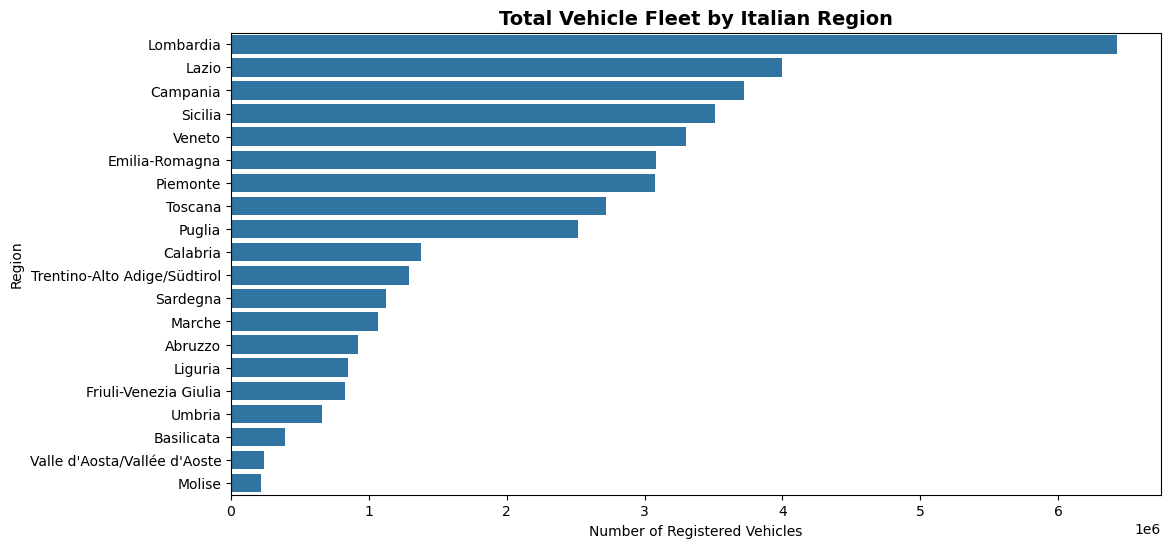

In [60]:
df_fleet_sort1 = df_fleet.sort_values(by='Parco_Auto_2024', ascending=False)

plt.figure(figsize=(12, 6))
fleet_plot1 = sns.barplot(
    data=df_fleet_sort1,
    x="Parco_Auto_2024",
    y="Regione"
)

plt.title("Total Vehicle Fleet by Italian Region", fontsize=14, weight="bold")
plt.xlabel("Number of Registered Vehicles")
plt.ylabel("Region")
plt.show()

This ranking identifies the core regions by pure fleet size. The top-tier regions contain the highest concentration of potential customers and operational vehicle assets in the country.

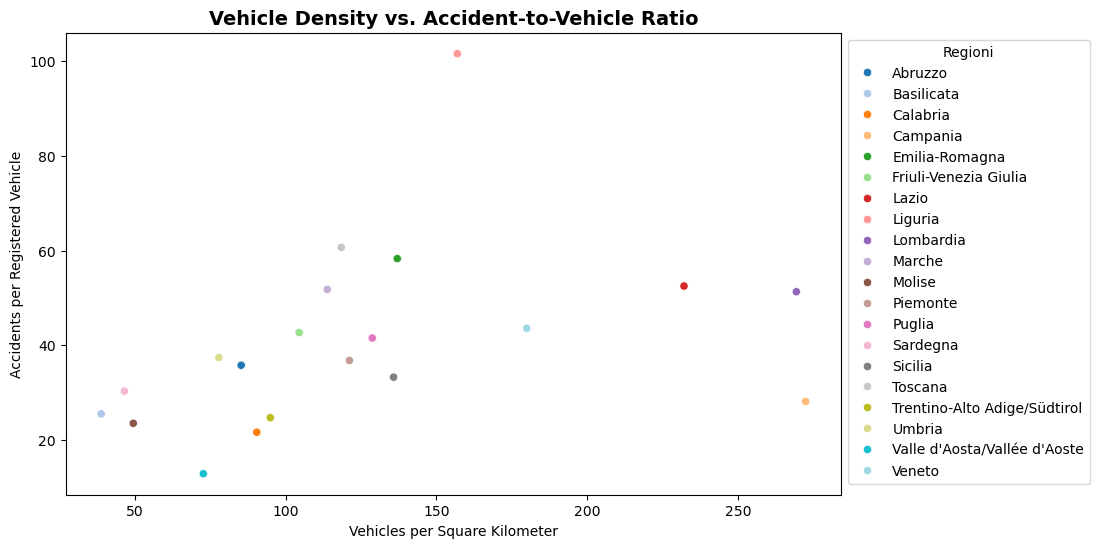

In [76]:
plt.figure(figsize=(10, 6))
fleet_plot2 = sns.scatterplot(
    data=df_fleet,
    x="Veicoli_Per_Kmq",
    y="Rapporto Incidenti/Veicoli",
    hue = "Regione",
    palette="tab20"
)
plt.legend(bbox_to_anchor=(1,1),title='Regioni')
plt.title("Vehicle Density vs. Accident-to-Vehicle Ratio", fontsize=14, weight="bold")
plt.xlabel("Vehicles per Square Kilometer")
plt.ylabel("Accidents per Registered Vehicle")
plt.show()

This scatter plot maps regional relationship between vehicles density and accidents per vehicles. Regions climbing toward the top-right combine heavy vehicle density with an elevated crash ratio per vehicle. These potentially represent critical zones where intevenctions are urgently needed.

Based on the empirical evidence gathered throughout this analysis, we could recomend:

Investment in Lombardy, specially in Milan. Lombardy holds the absolute maximum market volume with 6.42 million registered vehicles and a saturation of 269.29 vehicles/Kmq.

Investment in Liguria. Liguria holds an exceptional national peak in the "Rapporto Incidenti/Veicoli" (101.57 crashes per 1,000 vehicles). This proves that a vehicle driving in Liguria is much more likely to be involved in a crash than anywhere else in the country.

Invesment in the small-to-medium municipalities crowded in the high-per-capita risk quadrants.

In the upcoming notebook, we will transition from descriptive analysis to Predictive Analytics and/or Machine Learning.